In [32]:
# Best CTR via channel selection
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm

data_dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/cal10.bin'
num_rows = os.path.getsize(data_dir) // 6
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, 3))

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

def gaussianbg(x, a, mu, c, bg):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + bg


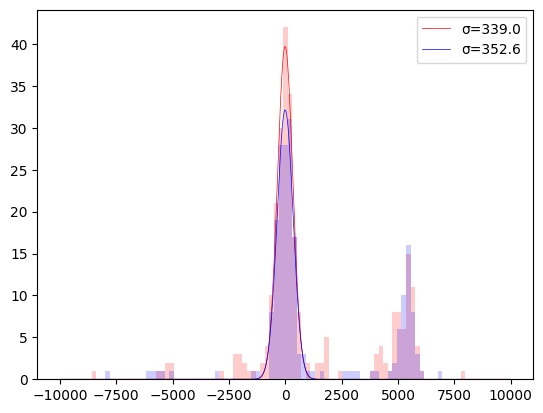

In [45]:
num = 4
channelL = data[data[:, 0] == num]
channelR = data[data[:, 1] == num]

bins = np.linspace(-10000, 10000, 100)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

hist1 = plt.hist(channelL[:, 2], bins = bins, color = 'red', alpha = 0.2)[0]
hist2 = plt.hist(channelR[:, 2], bins = bins, color = 'blue', alpha = 0.2)[0]
popt1, pcov1 = curve_fit(gaussian, bincenters, hist1, p0 = [5, 0, 500])
popt2, pcov2 = curve_fit(gaussian, bincenters, hist2, p0 = [5, 0, 500])
plt.plot(np.linspace(-10000, 10000, 500), gaussian(np.linspace(-10000, 10000, 500), *popt1), color = 'red', linewidth = 0.5, label = f'σ={round(np.abs(popt1[2]), 1)}')
plt.plot(np.linspace(-10000, 10000, 500), gaussian(np.linspace(-10000, 10000, 500), *popt2), color = 'blue', linewidth = 0.5, label = f'σ={round(np.abs(popt2[2]), 1)}')
plt.legend()
plt.show()
